# BUS 659: Machine Learning for Managers
## MIDTERM EXAM VERSION 2 (Take-Home, 72 Hours)

**Instructions:**
- This is a take-home exam to be completed within 72 hours of receipt
- You may use all course materials, notes, and online resources
- You must work independently - no collaboration with other students
- Submit your completed Jupyter notebook with all code executed and outputs visible
- Each question builds in complexity; partial credit will be given for attempted work
- Save your work frequently

**Datasets:** 
- Question 1: `../datasets/digital_advertising_campaigns.csv`
- Question 2: `../datasets/career_outcomes_survey.csv`

**Total Points:** 100 (50 per question)

**Academic Integrity Statement:** By submitting this exam, I affirm that all work is my own and I have neither given nor received unauthorized assistance.

# Matthew Tonks

In [59]:
# NAME: Matthew Tonks
# DATE: 2025-10-01

# I affirm that this work is entirely my own:
# SIGNATURE: Matthew Tonks

# I affirm that if I consulted AI models I typed their outputs on my own instead of copy/paste 
# SIGNATURE: Matthew Tonks

In [60]:
# Setup - DO NOT MODIFY THIS CELL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotnine import *
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-darkgrid')

print("Setup complete. You may begin.")

Setup complete. You may begin.


---
# QUESTION 1: Digital Advertising Campaign Analysis & Optimization (50 points)

You are a data analyst at a Fortune 500 company that spends $50M annually on digital advertising across multiple channels. The CMO has asked you to analyze the company's advertising campaigns to optimize spending and improve ROI.

**Dataset Description:** `digital_advertising_campaigns.csv` contains:
- `campaign_id`: Unique identifier for each campaign
- `campaign_date`: Date the campaign was launched
- `platform`: Advertising platform (Google, Facebook, Instagram, LinkedIn, Twitter, TikTok)
- `ad_type`: Type of ad (Video, Display, Search, Social, Native)
- `target_audience`: Target demographic (18-24, 25-34, 35-44, 45-54, 55+)
- `industry_vertical`: Product category being advertised
- `campaign_duration_days`: Length of campaign
- `ad_spend`: Total amount spent on the campaign (USD)
- `impressions`: Number of times the ad was shown
- `clicks`: Number of clicks on the ad
- `conversions`: Number of desired actions taken (purchases, signups, etc.)
- `revenue_generated`: Revenue attributed to the campaign (USD)
- `device_type`: Primary device type (Mobile, Desktop, Tablet)
- `geographic_region`: Region targeted (North America, Europe, Asia, etc.)
- `seasonality`: Quarter of the year (Q1, Q2, Q3, Q4)
- `creative_score`: Internal quality score of ad creative (1-100)

## Q1.a) Data Exploration and Quality Assessment (5 points)

1. Load the advertising dataset and check for data quality issues:
   - Display shape, data types, and missing values
   - Check for duplicate campaign_ids
   - Identify any logical inconsistencies (e.g., clicks > impressions, conversions > clicks)
   
2. Create efficiency metrics:
   - `CPM` (Cost per thousand impressions): (ad_spend / impressions) * 1000
   - `CTR` (Click-through rate): clicks / impressions
   - `conversion_rate`: conversions / clicks  
   - `ROAS` (Return on ad spend): revenue_generated / ad_spend
   - `profit_margin`: (revenue_generated - ad_spend) / revenue_generated
   
3. Remove problematic records and campaigns with impressions < 500

4. Create a correlation heatmap of all numeric variables and identify the top 3 correlations

(5000, 16)
  campaign_id                  campaign_date   platform  ad_type target_audience industry_vertical  \
0  CAMP_00001  2022-01-01 00:00:00.000000000   Facebook  Display           25-34           Finance   
1  CAMP_00002  2022-01-01 04:57:51.094218843     TikTok   Search           25-34     Entertainment   
2  CAMP_00003  2022-01-01 09:55:42.188437687   LinkedIn   Social           25-34        Healthcare   
3  CAMP_00004  2022-01-01 14:53:33.282656531  Instagram  Display           35-44            Retail   
4  CAMP_00005  2022-01-01 19:51:24.376875375     Google   Social           35-44            Retail   

   campaign_duration_days device_type geographic_region seasonality  creative_score  ad_spend  impressions  clicks  \
0                      30      Mobile            Europe          Q1       50.987617   5773.56       547758   12134   
1                       7      Mobile            Europe          Q1       62.138139   2847.36       267056    7848   
2                     

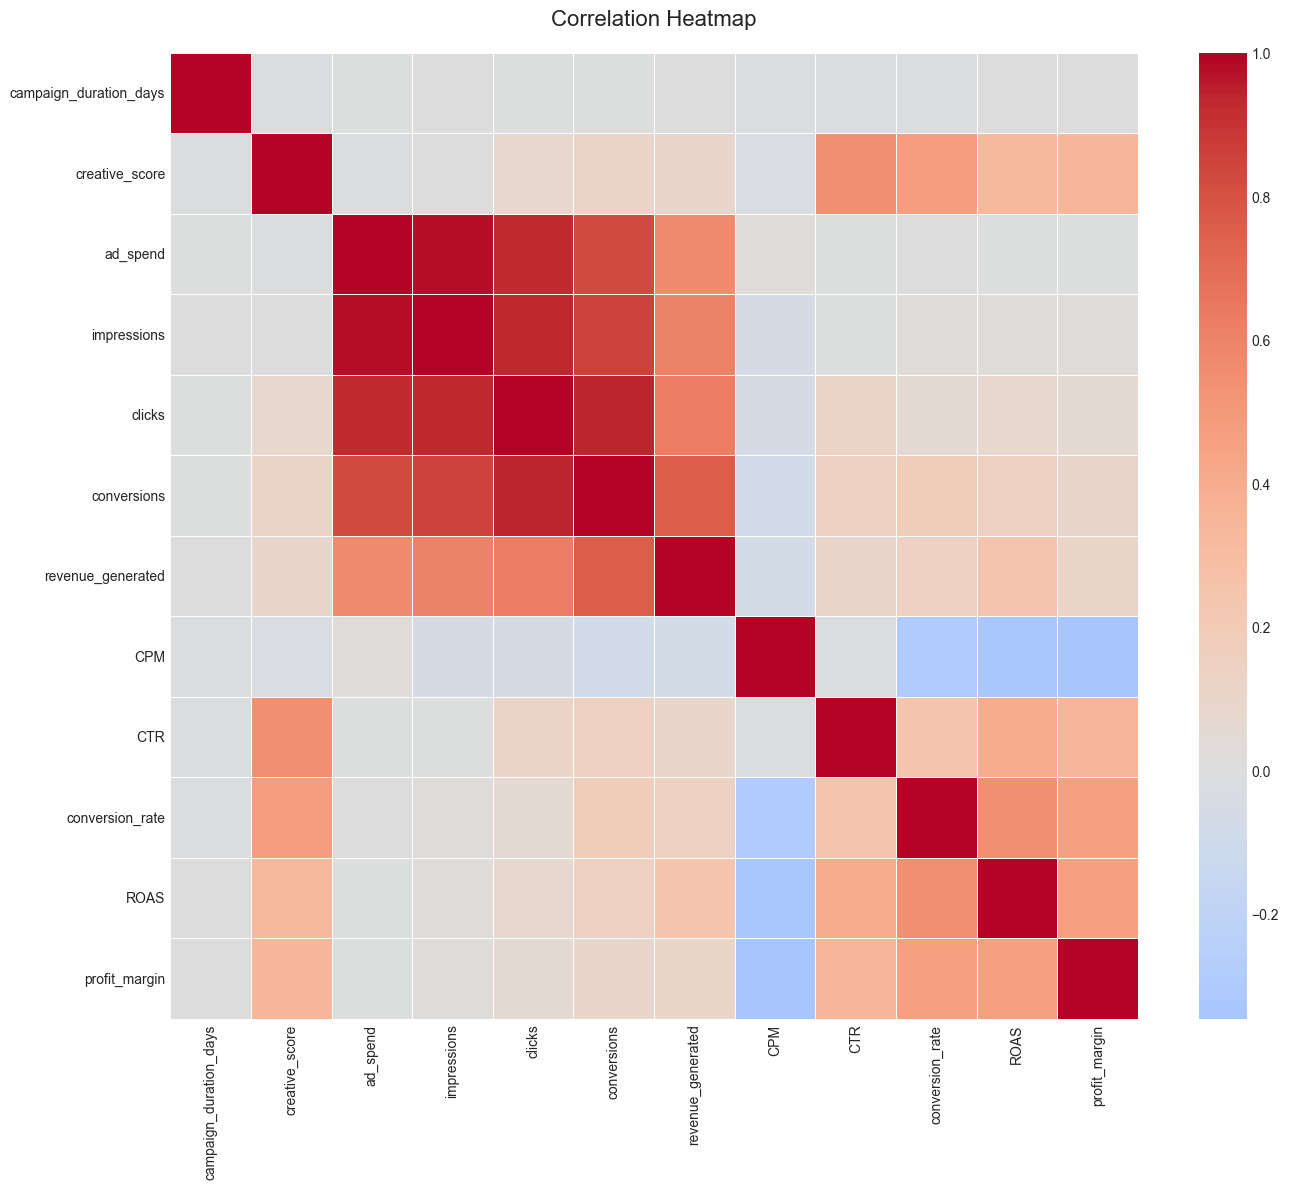

Top 3 variable pairs with highest correlation:
ad_spend & impressions: 0.9829
clicks & conversions: 0.9415
impressions & clicks: 0.9356


In [61]:
# Your code here
# Load the advertising dataset
# Update the path below to the correct location of your CSV file
ad_df = pd.read_csv('datasets/digital_advertising_campaigns.csv')
print(ad_df.shape)
print(ad_df.head())

print("Duplicate campaign_ids:", ad_df['campaign_id'].duplicated().sum())
print("Logical Inconsistencies:")
clicks_gt_impressions = (ad_df['clicks'] > ad_df['impressions']).sum()
conversions_gt_clicks = (ad_df['conversions'] > ad_df['clicks']).sum()
print(f"Clicks > Impressions: {clicks_gt_impressions} records")
print(f"Conversions > Clicks: {conversions_gt_clicks} records")



# 2. Create efficiency metrics
ad_df['CPM'] = (ad_df['ad_spend'] / ad_df['impressions']) * 1000
ad_df['CTR'] = ad_df['clicks'] / ad_df['impressions']
ad_df['conversion_rate'] = ad_df['conversions'] / ad_df['clicks']
ad_df['ROAS'] = ad_df['revenue_generated'] / ad_df['ad_spend']
ad_df['profit_margin'] = (ad_df['revenue_generated'] - ad_df['ad_spend']) / ad_df['revenue_generated']


# 3 

ad_df = ad_df[ad_df['impressions'] >= 500]

# 4 
numeric_cols = ad_df.select_dtypes(include=[np.number]).columns
correlation_matrix = ad_df[numeric_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'var1': correlation_matrix.columns[i],
            'var2': correlation_matrix.columns[j],
            'correlation': abs(correlation_matrix.iloc[i, j])
        })

top_3_corr = sorted(corr_pairs, key=lambda x: x['correlation'], reverse=True)[:3]

print("Top 3 variable pairs with highest correlation:")
for pair in top_3_corr:
    print(f"{pair['var1']} & {pair['var2']}: {pair['correlation']:.4f}")

## Q1.b) Time Series and Trend Analysis (8 points)

1. Convert campaign_date to datetime and extract temporal features:
   - Year, month, day of week, week of year
   - Is it a weekend campaign? (Saturday/Sunday)
   - Days since first campaign in dataset
   
2. Analyze performance trends over time:
   - Calculate monthly average ROAS, spend, and conversion rates
   - Compute 30-day and 90-day moving averages for ROAS
   - Identify months with significant performance changes (>20% from previous)
   - Which months perform best/worst and why?
   
3. Platform evolution analysis:
   - How has each platform's market share (% of total spend) changed over time?
   - Create a stacked area chart showing monthly spend distribution by platform
   - Which platforms are gaining/losing market share?
   - Calculate the trend (increasing/decreasing) for each platform's ROAS

In [62]:
# Q1.b - PART 1: Convert campaign_date and extract temporal features

ad_df['campaign_date'] = pd.to_datetime(ad_df['campaign_date'])
ad_df['campaign_year'] = ad_df['campaign_date'].dt.year
ad_df['campaign_month'] = ad_df['campaign_date'].dt.month
ad_df['day_of_week'] = ad_df['campaign_date'].dt.dayofweek  # Monday=0, Sunday=6
ad_df['week_of_year'] = ad_df['campaign_date'].dt.isocalendar().week
ad_df['is_weekend'] = (ad_df['day_of_week'] >= 5).astype(int)  # 1 if Sat/Sun, 0 otherwise
ad_df['days_since_first_campaign'] = (ad_df['campaign_date'] - ad_df['campaign_date'].min()).dt.days

# Create year_month column for monthly aggregations
ad_df['year_month'] = ad_df['campaign_date'].dt.to_period('M').astype(str)

print("Temporal Features Created:")
print(ad_df[['campaign_date', 'campaign_year', 'campaign_month', 'day_of_week', 
            'week_of_year', 'is_weekend', 'days_since_first_campaign']].head(10))

Temporal Features Created:
                  campaign_date  campaign_year  campaign_month  day_of_week  week_of_year  is_weekend  \
0 2022-01-01 00:00:00.000000000           2022               1            5            52           1   
1 2022-01-01 04:57:51.094218843           2022               1            5            52           1   
2 2022-01-01 09:55:42.188437687           2022               1            5            52           1   
3 2022-01-01 14:53:33.282656531           2022               1            5            52           1   
4 2022-01-01 19:51:24.376875375           2022               1            5            52           1   
5 2022-01-02 00:49:15.471094218           2022               1            6            52           1   
6 2022-01-02 05:47:06.565313062           2022               1            6            52           1   
7 2022-01-02 10:44:57.659531906           2022               1            6            52           1   
8 2022-01-02 15:42:48.753750

In [63]:
# Q1.b - PART 2: Analyze performance trends over time

# Calculate monthly averages
monthly_metrics = ad_df.groupby('year_month').agg({
    'ROAS': 'mean',
    'ad_spend': 'sum',
    'conversion_rate': 'mean'
}).reset_index().rename(columns={
    'ROAS': 'avg_ROAS',
    'ad_spend': 'total_spend',
    'conversion_rate': 'avg_conversion_rate'
})

# Sort by date for time series operations
ad_df_sorted = ad_df.sort_values('campaign_date').reset_index(drop=True)

# Calculate 30-day and 90-day moving averages for ROAS
ad_df_sorted['ROAS_30d_ma'] = ad_df_sorted['ROAS'].rolling(window=30, min_periods=1).mean()
ad_df_sorted['ROAS_90d_ma'] = ad_df_sorted['ROAS'].rolling(window=90, min_periods=1).mean()

# Calculate month-over-month % change in ROAS
monthly_metrics['ROAS_pct_change'] = monthly_metrics['avg_ROAS'].pct_change() * 100

# Identify months with significant performance changes (>20%)
significant_change = monthly_metrics[monthly_metrics['ROAS_pct_change'].abs() > 20]
print("Months with >20% ROAS change from previous month:")
print(significant_change[['year_month', 'avg_ROAS', 'ROAS_pct_change']])

# Find top 3 best and worst performing months
best_months = monthly_metrics.nlargest(3, 'avg_ROAS')
worst_months = monthly_metrics.nsmallest(3, 'avg_ROAS')

print("\n" + "="*80)
print("Top 3 BEST performing months:")
print(best_months[['year_month', 'avg_ROAS', 'total_spend', 'avg_conversion_rate']])

print("\nTop 3 WORST performing months:")
print(worst_months[['year_month', 'avg_ROAS', 'total_spend', 'avg_conversion_rate']])

Months with >20% ROAS change from previous month:
   year_month   avg_ROAS  ROAS_pct_change
9     2022-10   8.935250        24.205065
21    2023-10  10.227796        21.364378
28    2024-05   9.466443        23.636063
33    2024-10  11.324822        20.047793

Top 3 BEST performing months:
   year_month   avg_ROAS  total_spend  avg_conversion_rate
33    2024-10  11.324822   2586065.15             0.068529
10    2022-11  10.365871   2520976.26             0.071357
23    2023-12  10.312526   3873069.84             0.069751

Top 3 WORST performing months:
   year_month  avg_ROAS  total_spend  avg_conversion_rate
8     2022-09  7.193949   3681809.44             0.053290
27    2024-04  7.656700   3476316.58             0.056108
3     2022-04  7.751852   2403591.20             0.055681


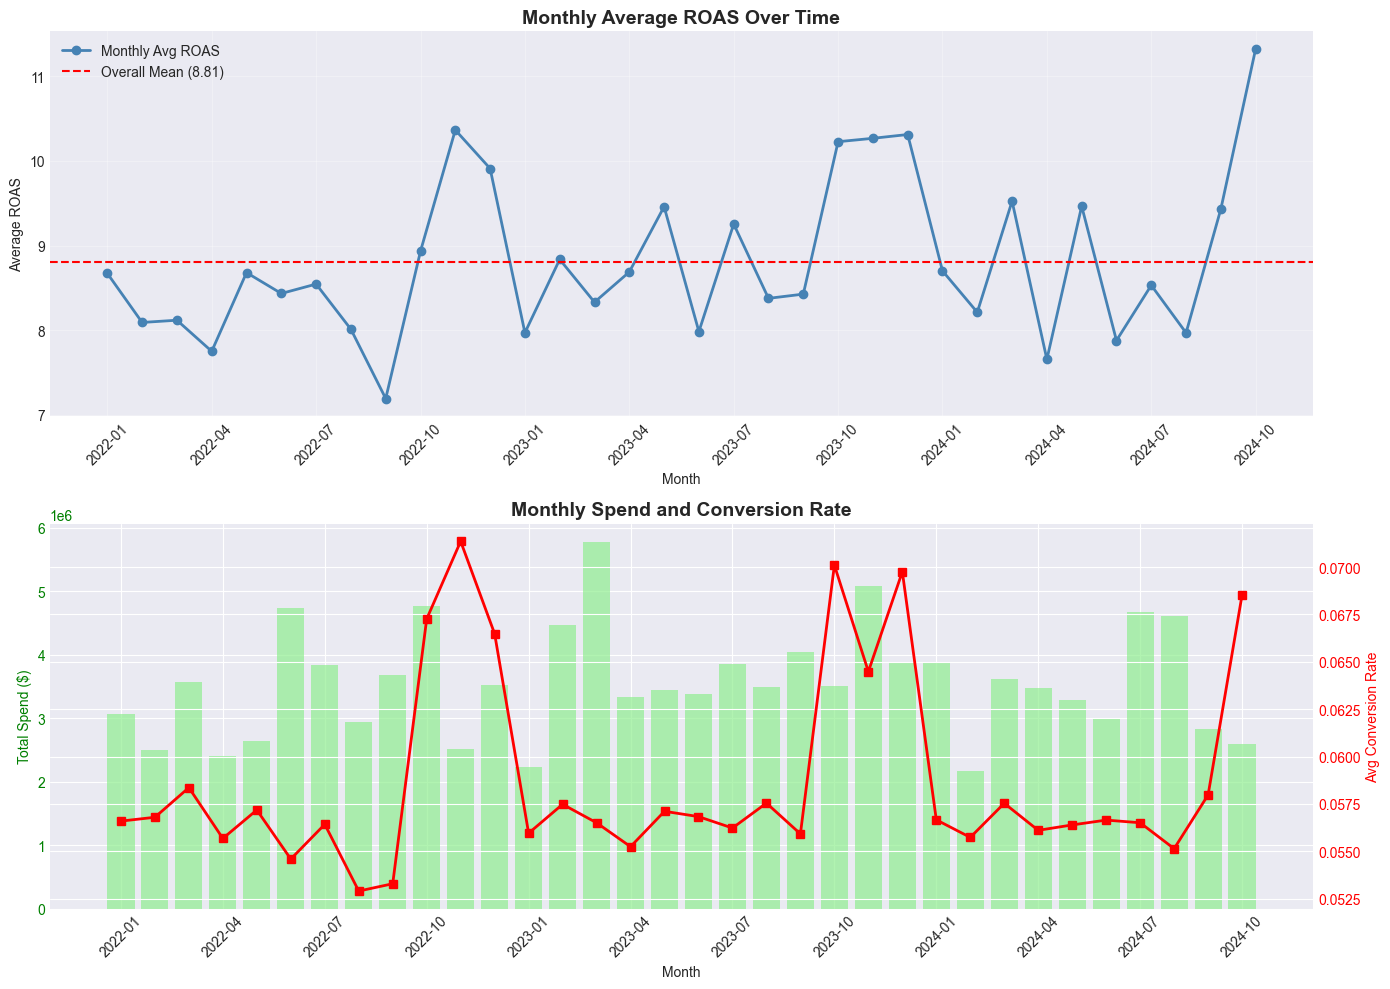

In [64]:
# Q1.b - PART 2 (continued): Visualization of ROAS trends

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Monthly ROAS with moving averages
axes[0].plot(range(len(monthly_metrics)), monthly_metrics['avg_ROAS'], 
             marker='o', label='Monthly Avg ROAS', linewidth=2, color='steelblue')
axes[0].axhline(y=monthly_metrics['avg_ROAS'].mean(), color='red', 
                linestyle='--', label=f'Overall Mean ({monthly_metrics["avg_ROAS"].mean():.2f})', linewidth=1.5)
axes[0].set_title('Monthly Average ROAS Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average ROAS')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, len(monthly_metrics), 3))
axes[0].set_xticklabels(monthly_metrics['year_month'].iloc[::3], rotation=45)

# Plot 2: Monthly spend and conversion rate
ax2 = axes[1]
ax2.bar(range(len(monthly_metrics)), monthly_metrics['total_spend'], 
        alpha=0.7, label='Total Spend', color='lightgreen')
ax2.set_xlabel('Month')
ax2.set_ylabel('Total Spend ($)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_xticks(range(0, len(monthly_metrics), 3))
ax2.set_xticklabels(monthly_metrics['year_month'].iloc[::3], rotation=45)

# Twin axis for conversion rate
ax2_twin = ax2.twinx()
ax2_twin.plot(range(len(monthly_metrics)), monthly_metrics['avg_conversion_rate'], 
              color='red', marker='s', linewidth=2, label='Avg Conversion Rate')
ax2_twin.set_ylabel('Avg Conversion Rate', color='red')
ax2_twin.tick_params(axis='y', labelcolor='red')

axes[1].set_title('Monthly Spend and Conversion Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

There seems to be a trend for spending seems to be about the same with some growth on the Monthly ad spend is  fairly standard around a mean with a few peaks scattered. 

Over the holiday season (October, November, December) there is a seasonal trend where the values peak and then return to a standard baseline

<Figure size 1400x800 with 0 Axes>

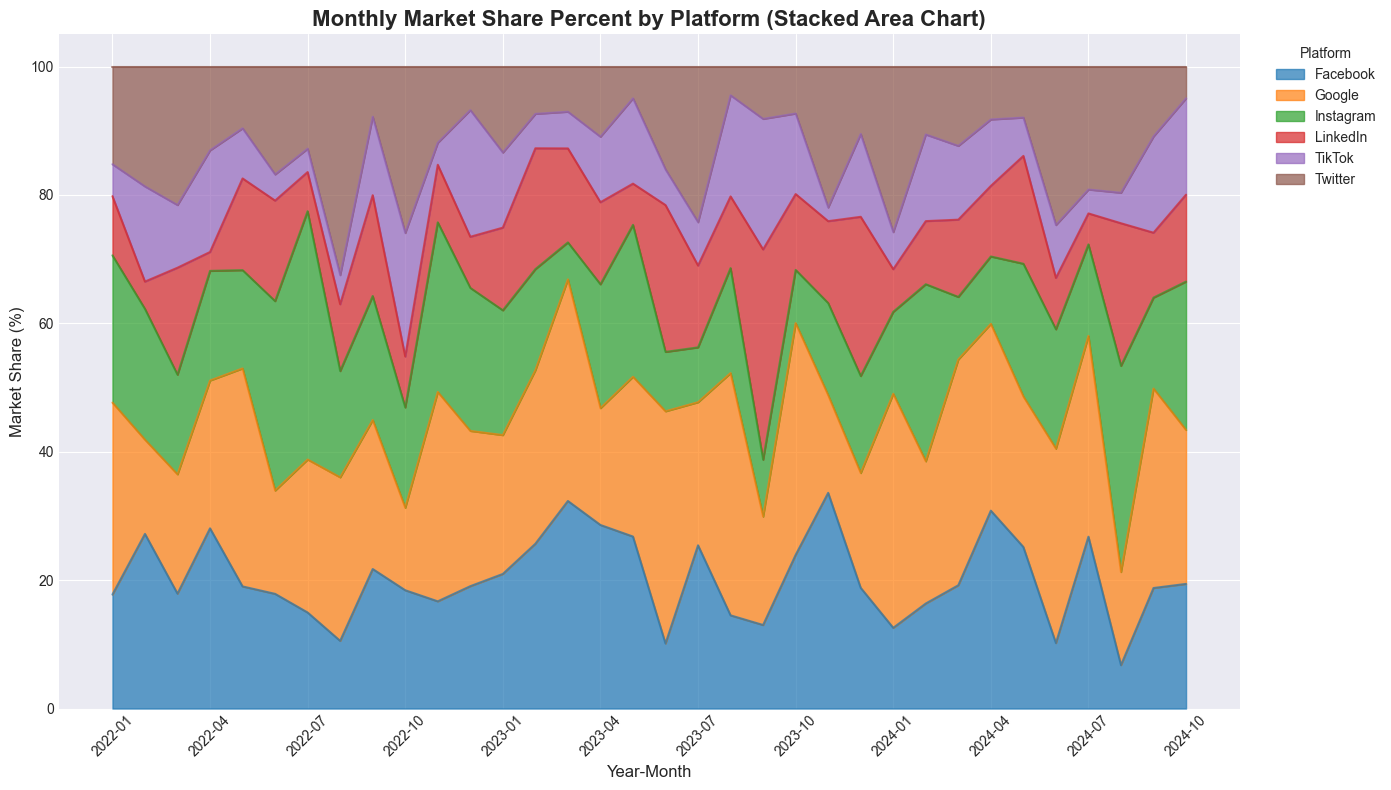

In [77]:
# Stacked area chart: monthly market share percent by platform
plt.figure(figsize=(14, 8))
pivot_share.plot.area(figsize=(14, 8), alpha=0.7)
plt.title('Monthly Market Share Percent by Platform (Stacked Area Chart)', fontsize=16, fontweight='bold')
plt.ylabel('Market Share (%)', fontsize=12)
plt.xlabel('Year-Month', fontsize=12)
plt.legend(title='Platform', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.xticks(range(0, len(pivot_share), 3), pivot_share.index[::3], rotation=45)
plt.tight_layout()
plt.show()



1. Market Share (% of Spend) Over Time
	- Facebook & Google: The most stable core spenders across the timeline, with periodic spikes. Google in particular captured a growing share post-2023, overtaking other platforms in several high-spend months.
	- Instagram: Volatile. It peaks strongly in mid-2022 and mid-2024 but sees contractions afterward, suggesting budget reallocation to better-performing channels.
	- LinkedIn: Consistently moderate contributor; share is steady but never dominant. It acts as a secondary spend channel.
	- TikTok: Noticeable ramp-up starting 2023, becoming a consistent middle-tier spender by 2024. Market share is rising, showing confidence in its ROI.
	- Twitter: Highly volatile — some peaks in 2022 and mid-2023 but declining share by late 2024. Looks like budgets are being shifted away.

2. Platforms Gaining/Losing Market Share
- Gaining:
	- Google → Increasing dominance in spend distribution.
	- TikTok → Strong growth trajectory, carving out more consistent share.
- Losing:
	- Twitter → Significant drop-off in spend after 2023.
	- Instagram → From high share in 2022 to a smaller portion by 2024.
- Steady:
	- Facebook → Still strong but not growing as aggressively as Google/TikTok.
	- LinkedIn → Stable, niche role.

3. ROAS Trend by Platform

	- Google → Increasing trend; strong correlation with best-performing months (e.g., Oct/Dec spikes). Likely highest efficiency scaling.
	- Facebook → Stable to slightly decreasing; reliable but less explosive growth.
	- Instagram → Decreasing; early efficiency eroded over time.
	- LinkedIn → Flat; small but steady contributor, ROI unlikely to vary heavily.
	- TikTok → Increasing; gaining traction, especially mid-2023 onward, likely strong incremental ROAS.
	- Twitter → Declining; aligns with budget cuts and underperformance.

4. Strategic Takeaways
	- Shift budget toward Google and TikTok → they show both growing spend share and rising ROAS.
	- Maintain baseline on Facebook → stable returns, but don’t over-invest given lack of growth.
	- Cut back on Twitter/Instagram → declining ROAS and shrinking effectiveness.
	- Use LinkedIn surgically → B2B/niche targeting rather than scaling.
	- Seasonality still dominates (Q4 strong) → reinforce budgets on Google/TikTok in Oct–Dec while cutting low-ROAS platforms.


## Q1.c) Campaign Performance Segmentation and Analysis (9 points)

1. Performance-based campaign segmentation:
   - Divide campaigns into performance tiers based on ROAS:
     * High performers: ROAS > 75th percentile
     * Medium performers: 25th percentile < ROAS < 75th percentile  
     * Low performers: ROAS < 25th percentile
   - Profile each tier: What characteristics do they share?
   - Create visualizations comparing tiers across key metrics
   
2. Industry vertical deep dive:
   - Calculate average ROI by industry: (revenue_generated - ad_spend) / ad_spend
   - Which industry verticals have the highest/lowest ROI?
   - Create a treemap showing spend allocation vs revenue generation by industry
   - Are we over/under-investing in any verticals based on their ROI?
   
3. Device and platform synergy analysis:
   - Create a cross-tabulation of device_type vs platform performance (ROAS)
   - Calculate lift: How much better do mobile ads perform on mobile-first platforms (Instagram/TikTok)?
   - Test hypothesis using t-test: Mobile campaigns perform better on Instagram/TikTok than on LinkedIn/Facebook
   - Create a heatmap showing ROAS by platform and device combination

In [72]:
# Your code here

# Scaffolding for performance segmentation:
# Example for creating performance tiers:
percentiles = ad_df['ROAS'].quantile([0.25, 0.75])
ad_df['performance_tier'] = pd.cut(ad_df['ROAS'], 
                                   bins=[-np.inf, percentiles[0.25], percentiles[0.75], np.inf],
                                   labels=['Low', 'Medium', 'High'])

# Profile each tier
tier_profiles = ad_df.groupby('performance_tier').agg({
    'ad_spend': ['mean', 'median', 'sum'],
    'ROAS': ['mean', 'median'],
    'CTR': 'mean',
    'conversion_rate': 'mean',
    'creative_score': 'mean',
    'campaign_duration_days': 'mean',
    'impressions': 'mean',
    'conversions': 'mean'
}).round(2)
print(tier_profiles)

import pandas as pd
import plotly.express as px

# Flatten MultiIndex if needed
tp = tier_profiles.copy()
tp.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in tp.columns]
tp = tp.reset_index().rename(columns={'performance_tier': 'tier'})

# Select only the metrics to compare
metrics = ['ad_spend_mean', 'impressions_mean', 'conversion_rate_mean']

# Reshape for plotting
df = tp[['tier'] + metrics].melt(id_vars='tier', var_name='metric', value_name='value')



                  ad_spend                         ROAS          CTR conversion_rate creative_score  \
                      mean   median          sum   mean median  mean            mean           mean   
performance_tier                                                                                      
Low               24848.33  8662.74  31060409.42   1.90   1.94  0.02            0.04          49.21   
Medium            24607.26  8193.70  61518160.94   6.33   5.91  0.02            0.06          59.75   
High              22562.76  7998.31  28203455.64  20.71  17.01  0.03            0.08          69.13   

                 campaign_duration_days impressions conversions  
                                   mean        mean        mean  
performance_tier                                                 
Low                               28.44  2319872.20     2091.93  
Medium                            28.74  2498415.12     3546.12  
High                              28.86  2551925.36

In [78]:
import pandas as pd
import plotly.express as px

# Flatten MultiIndex if needed
tp = tier_profiles.copy()
tp.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in tp.columns]
tp = tp.reset_index().rename(columns={'performance_tier': 'tier'})

# Extract only impressions vs conversions for scatter
df = tp[['tier', 'impressions_mean', 'conversions_mean']]

# Scatter plot: impressions vs conversions, color by tier
fig = px.scatter(
    df,
    x="impressions_mean",
    y="conversions_mean",
    color="tier",
    symbol="tier",
    size="conversions_mean",   # bubble size ~ number of conversions
    text="tier",
    title="Tier Comparison — Impressions vs Conversions"
)

# Improve layout
fig.update_traces(textposition="top center")
fig.update_layout(
    xaxis_title="Average Impressions",
    yaxis_title="Average Conversions",
    legend_title="Performance Tier",
    hovermode="closest"
)

fig.show()

The tiers seem to have an exponential growth between the tiers where the conversion

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px



# Ensure tier order
tier_order = ['High', 'Medium', 'Low']
ad_df['performance_tier'] = pd.Categorical(ad_df['performance_tier'], categories=tier_order, ordered=True)

# ---------------------------
# 2) (Optional) Tier profiles table
# ---------------------------
tier_profiles = ad_df.groupby('performance_tier').agg({
    'ad_spend': ['mean', 'median', 'sum'],
    'ROAS': ['mean', 'median'],
    'CTR': 'mean',
    'conversion_rate': 'mean',
    'creative_score': 'mean',
    'campaign_duration_days': 'mean',
    'impressions': 'mean',
    'conversions': 'mean'
}).round(2)

# ---------------------------
# 3) Plots
# ---------------------------

# Plot 1: Impressions vs Conversions (color by tier)
fig1 = px.scatter(
    ad_df,
    x='impressions',
    y='conversions',
    color='performance_tier',
    symbol='performance_tier',
    size='conversions',  # bubble sized by conversions
    hover_data={
        'performance_tier': True,
        'ad_spend': ':.0f',
        'ROAS': ':.2f',
        'CTR': ':.2%',
        'conversion_rate': ':.2%',
        'impressions': ':,',
        'conversions': ':,'
    },
    title='Impressions vs Conversions — Colored by Performance Tier',
)
fig1.update_layout(
    xaxis_title='Impressions',
    yaxis_title='Conversions',
    legend_title='Performance Tier',
    hovermode='closest'
)

# Plot 2: Faceted small multiples by tier
fig2 = px.scatter(
    ad_df,
    x='impressions',
    y='conversions',
    color='performance_tier',
    facet_col='performance_tier',
    facet_col_spacing=0.06,
    size='conversions',
    hover_data={
        'performance_tier': True,
        'ad_spend': ':.0f',
        'ROAS': ':.2f',
        'CTR': ':.2%',
        'conversion_rate': ':.2%',
        'impressions': ':,',
        'conversions': ':,'
    },
    title='Impressions vs Conversions — Split by Performance Tier'
)
fig2.update_layout(
    xaxis_title='Impressions',
    yaxis_title='Conversions',
    legend_title='Performance Tier',
)
# Optional: hide redundant legends in facets
for a in fig2.select_traces():
    a.showlegend = False

# Plot 3: Ad Spend vs Conversion Rate (color by tier)
fig3 = px.scatter(
    ad_df,
    x='ad_spend',
    y='conversion_rate',
    color='performance_tier',
    symbol='performance_tier',
    size='ad_spend',
    hover_data={
        'performance_tier': True,
        'ad_spend': ':.0f',
        'ROAS': ':.2f',
        'CTR': ':.2%',
        'conversion_rate': ':.2%',
        'impressions': ':,',
        'conversions': ':,'
    },
    title='Ad Spend vs Conversion Rate — Colored by Performance Tier'
)
fig3.update_layout(
    xaxis_title='Ad Spend (USD)',
    yaxis_title='Conversion Rate',
    legend_title='Performance Tier',
    hovermode='closest'
)
fig3.update_yaxes(tickformat='.1%')

# Show the figures
fig1.show()
fig2.show()
fig3.show()

In [80]:
import plotly.express as px
# Calculate ROI for each campaign if not already present
ad_df['ROI'] = (ad_df['revenue_generated'] - ad_df['ad_spend']) / ad_df['ad_spend']
fig = px.treemap(ad_df, path=['industry_vertical'], values='ad_spend',
                 color='ROI', color_continuous_scale='RdYlGn')
fig.show()



In [83]:
import pandas as pd

# Group by industry_vertical (correct column name)
vertical_perf = ad_df.groupby('industry_vertical').agg({
    'ad_spend': 'sum',
    'conversions': 'sum',
    'ROAS': 'mean'
}).reset_index()

# Calculate portfolio-level totals
total_spend = vertical_perf['ad_spend'].sum()
total_conversions = vertical_perf['conversions'].sum()

# Share of spend vs. share of conversions
vertical_perf['spend_share'] = vertical_perf['ad_spend'] / total_spend
vertical_perf['conversion_share'] = vertical_perf['conversions'] / total_conversions

# Investment gap (positive = over-invested, negative = under-invested)
vertical_perf['investment_gap'] = vertical_perf['spend_share'] - vertical_perf['conversion_share']

# Flag categories
def classify(gap):
    if gap > 0.05:   # more than +5% over-spend
        return "Over-invested"
    elif gap < -0.05: # more than -5% under-spend
        return "Under-invested"
    else:
        return "Balanced"

vertical_perf['investment_flag'] = vertical_perf['investment_gap'].apply(classify)

# Sort for readability
vertical_perf = vertical_perf.sort_values('investment_gap', ascending=False)

print(vertical_perf[['industry_vertical','ad_spend','conversions','ROAS','spend_share','conversion_share','investment_gap','investment_flag']])

  industry_vertical     ad_spend  conversions      ROAS  spend_share  conversion_share  investment_gap investment_flag
3        Healthcare  17338246.15      2350056  8.223166     0.143550          0.124404        0.019146        Balanced
1     Entertainment  18817641.69      2926378  9.422873     0.155798          0.154913        0.000885        Balanced
6            Travel  12631856.99      1969997  8.556047     0.104584          0.104285        0.000299        Balanced
2           Finance  18109576.37      2865586  9.120972     0.149936          0.151695       -0.001759        Balanced
5        Technology  19302743.57      3109941  8.694917     0.159815          0.164630       -0.004815        Balanced
4            Retail  23576795.34      3783998  9.114059     0.195201          0.200312       -0.005111        Balanced
0         Education  11005165.89      1884519  7.982973     0.091116          0.099760       -0.008644        Balanced


In [ ]:

from scipy import stats
mobile_instagram = ad_df[(ad_df['device_type']=='Mobile') & 
                         (ad_df['platform'].isin(['Instagram','TikTok']))]['ROAS']
mobile_linkedin = ad_df[(ad_df['device_type']=='Mobile') & 
                        (ad_df['platform'].isin(['LinkedIn','Facebook']))]['ROAS']
t_stat, p_value = stats.ttest_ind(mobile_instagram, mobile_linkedin)

## Q1.d) Predictive Modeling for Campaign Success (10 points)

1. Define campaign success and prepare data:
   - Create binary target: successful = 1 if ROAS > median AND conversions > median, else 0
   - Split data 70/30 train/test (set random_state=42)
   - What's the baseline accuracy (majority class)?
   - Check class balance - is the target variable balanced?

2. Feature engineering:
   - Standardize numeric features: creative_score, ad_spend, campaign_duration_days
   - One-hot encode categorical variables
   - Create derived features: spend_per_day, CTR × creative_score

3. Model building and comparison:
   - **Linear Regression for ROAS prediction:**
     * Target: ROAS (continuous)
     * Features: all engineered features
     * Report R-squared, RMSE, MAE
   - **Logistic Regression for success classification:**
     * Target: successful (binary)
     * Try different regularization strengths (C = 0.01, 0.1, 1, 10)
     * Report accuracy, precision, recall, F1-score, ROC-AUC
   - Which model is more useful for campaign optimization? Why?

4. Model evaluation and business value:
   - Generate ROC curve and find optimal threshold for logistic model
   - Create confusion matrix for logistic model
   - Calculate expected value: If we only run campaigns predicted as successful, what's the impact on overall ROAS?
   - What percentage of budget would be saved by avoiding unsuccessful campaigns?

In [ ]:
# Your code here


In [ ]:
# Your code here


**YOUR STRATEGIC MEMO TO THE CMO:**

[Write your comprehensive response here]


## Q1.e) CMO Strategic Recommendation (10 points)

Write a comprehensive strategic memo (400-500 words) to the CMO that includes:

1. **Platform Strategy:** Based on your analysis, which 2-3 platforms should receive the majority of the $50M annual budget? Provide specific allocation percentages and expected returns.

2. **Audience Targeting Framework:** Which demographic segments offer the best ROI? Should the company pursue a broad or narrow targeting strategy? How should this vary by platform?

3. **Creative Investment Decision:** Given the impact of creative scores on performance, should the company invest more in creative development? Quantify the expected ROI of improving creative quality.

4. **Testing & Learning Agenda:** Propose 3 specific experiments the marketing team should run in the next quarter to optimize performance. Include sample sizes and success metrics.

5. **Risk Mitigation:** What are the key risks in your recommendations (e.g., platform dependency, audience saturation)? How can the company hedge against these risks?

6. **Performance Targets:** Set specific, measurable KPI targets for the next year based on your optimization recommendations.

Support all recommendations with specific data from your analysis.

## Q2.a) Data Preparation and Exploratory Analysis (5 points)

1. Load the career outcomes dataset and perform initial exploration:
   - Check shape, data types, and missing values
   - Handle missing values appropriately (document your approach)
   - Check for any impossible values (e.g., negative salaries, GPA > 4.0)

2. Create the following derived features:
   - `log_salary_current`: Natural log of current salary
   - `log_salary_starting`: Natural log of starting salary  
   - `salary_growth`: (salary_current - salary_starting) / salary_starting
   - `elite_university`: 1 if university_tier in ['Top 10', 'Top 50'], else 0
   - `stem_major`: 1 if major in ['Engineering', 'Computer Science', 'Data Science', 'Mathematics'], else 0

3. Create visualizations:
   - Distribution of salary_current (histogram with normal curve overlay)
   - Distribution of log_salary_current (is it more normal?)
   - Scatter plot matrix of: GPA, years_experience, salary_current, job_satisfaction

In [ ]:
# Your code here


## Q2.b) Linear Regression Model Building (10 points)

1. Build a baseline linear regression model:
   - Dependent variable: salary_current
   - Independent variables: years_experience, GPA, internship_count, elite_university, stem_major
   - Split data 70/30 train/test
   - Report coefficients, R-squared, and p-values

2. Build an improved model with log transformation:
   - Dependent variable: log_salary_current
   - Add categorical variables (properly encoded): major, industry
   - Add polynomial term: years_experience²
   - Compare with baseline model

3. Model evaluation and visualization:
   - Calculate RMSE and MAE for both models on test set
   - Create actual vs predicted scatter plots for both models
   - Plot residuals vs fitted values - check for heteroscedasticity
   - Which model performs better and why?

4. Coefficient interpretation:
   - Interpret the coefficient for years_experience in both models
   - In the log model, what does a 0.05 coefficient mean in percentage terms?
   - Calculate the salary difference between STEM and non-STEM majors

In [ ]:
# Your code here


## Q2.c) Log-Log Model and Elasticity Analysis (8 points)

1. Build a log-log regression model:
   - Dependent variable: log_salary_current
   - Independent variables: log(years_experience + 1), log(GPA), log(internship_count + 1)
   - Add dummy variables for major categories
   - Report all coefficients with standard errors

2. Elasticity interpretation:
   - What is the elasticity of salary with respect to years_experience?
   - If someone has 10% more internships, what % change in salary is expected?
   - Which variable has the highest elasticity?
   - Are any elasticities greater than 1 (elastic) or less than 1 (inelastic)?

3. Compare model specifications:
   - Linear-Linear (from Q2.b part 1)
   - Log-Linear (from Q2.b part 2)
   - Log-Log (from this section)
   - Which specification has the best fit? Use AIC and BIC for comparison

4. Marginal effects:
   - Calculate marginal effect of one additional year of experience at:
     * 1 year of experience
     * 5 years of experience
     * 10 years of experience
   - Does the marginal effect diminish? Show graphically.

In [ ]:
# Your code here

# Scaffolding for log-log model:
# Remember: In a log-log model, coefficients represent elasticities
# If log(y) = β₀ + β₁*log(x), then β₁ is the elasticity
# Interpretation: A 1% increase in x leads to β₁% increase in y

# Example:
# career_df['log_years'] = np.log(career_df['years_experience'] + 1)
# career_df['log_gpa'] = np.log(career_df['gpa'])
# career_df['log_internships'] = np.log(career_df['internship_count'] + 1)

# For marginal effects at different points:
# marginal_effect = coefficient * (salary / years_exp)
# At 1 year: marginal_1 = coef * (predicted_salary_1yr / 1)
# At 5 years: marginal_5 = coef * (predicted_salary_5yr / 5)

## Q2.d) Logistic Regression for High Earner Prediction (12 points)

1. Create binary target variable:
   - `high_earner`: 1 if salary_current > 75th percentile, 0 otherwise
   - What percentage of the sample are high earners?
   - Is the dataset imbalanced?

2. Build logistic regression model:
   - Use same features as linear regression plus technical_skills and leadership_roles
   - Split 70/30 train/test (same split as before for consistency)
   - Use L2 regularization (C=1.0)
   - Report coefficients and odds ratios

3. Model evaluation - Classification metrics:
   - Generate predictions using 0.5 threshold
   - Create confusion matrix with labels
   - Calculate: Accuracy, Precision, Recall, F1-score
   - What is the baseline accuracy (always predict majority class)?

4. ROC Analysis:
   - Plot ROC curve with AUC score
   - Find optimal threshold using Youden's J statistic
   - How do metrics change at the optimal threshold?
   - Plot precision-recall curve (important for imbalanced data)

5. Probability calibration:
   - Create a calibration plot (predicted vs actual probabilities)
   - Are the predicted probabilities well-calibrated?
   - Show distribution of predicted probabilities for both classes

In [ ]:
# Your code here


## Q2.e) Model Comparison and Practical Applications (8 points)

1. Model performance comparison:
   - Compare your linear regression models (baseline vs log-transformed)
   - Create a summary table with R², RMSE, MAE for each model
   - Which model would you recommend and why?
   - Plot prediction errors for both models side by side

2. Scenario analysis using your models:
   - Predict salaries for these profiles using your best linear model:
     * New grad: STEM major, 3.5 GPA, 2 internships, elite university
     * New grad: Liberal Arts major, 3.8 GPA, 1 internship, regional university
     * 5 years experience: Business major, 3.2 GPA, 3 internships
   - What's the salary difference and what drives it?

3. Model insights and recommendations:
   - Based on both linear and logistic models, what are the top 3 factors for salary success?
   - If a student can only improve ONE thing, what should it be?
   - Create a "salary calculator" formula students can use

In [ ]:
# Your code here

# Scaffolding for model comparison:
# Example for creating comparison table:
# comparison_results = pd.DataFrame({
#     'Model': ['Baseline Linear', 'Log-Transformed'],
#     'R²': [baseline_r2, log_model_r2],
#     'RMSE': [baseline_rmse, log_model_rmse],
#     'MAE': [baseline_mae, log_model_mae]
# })

# Example for scenario predictions:
# new_grad_stem = pd.DataFrame({
#     'years_experience': [0],
#     'gpa': [3.5],
#     'internship_count': [2],
#     'elite_university': [1],
#     'stem_major': [1]
# })
# predicted_salary = model.predict(new_grad_stem)[0]

# Example for plotting prediction errors:
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# errors_baseline = y_test - y_pred_baseline
# errors_log = y_test - y_pred_log
# axes[0].hist(errors_baseline, bins=30)
# axes[0].set_title('Baseline Model Errors')
# axes[1].hist(errors_log, bins=30)
# axes[1].set_title('Log Model Errors')

## Q2.f) Business Insights and Model Deployment Strategy (7 points)

Write a comprehensive report (400-500 words) for the university administration that addresses:

1. **Salary Prediction Model Insights:**
   - Based on your linear regression results, which factors most strongly predict salary?
   - How much does each additional year of experience add to salary?
   - What is the ROI of different majors based on the model?

2. **High Earner Identification:**
   - From the logistic regression, what profile predicts a high earner?
   - If the university wants to help more students become high earners, what should they focus on?
   - What is the relative importance of GPA vs internships vs major choice?

3. **Model Limitations:**
   - What are the limitations of using historical data for future predictions?
   - How might economic conditions affect model validity?
   - What assumptions does the model make?

4. **Deployment Recommendations:**
   - Which model (linear or logistic) would be more useful for students?
   - How often should models be retrained?
   - What additional data would improve predictions?
   - Propose a simple scoring tool based on your models

5. **Actionable Recommendations:**
   - Three specific actions the university should take to improve graduate outcomes
   - Target metrics for success (e.g., increase average starting salary by X%)
   - Expected impact of recommended interventions

Include specific numbers from your analysis to support all claims.

**YOUR STUDENT ADVISORY FRAMEWORK:**

[Write your comprehensive response here]


---
## BONUS QUESTION (Optional, 10 points)

Create an interactive dashboard (using plotly) that allows students to:
1. Input their profile (major, GPA, university tier, etc.)
2. See predicted salary ranges for different industries
3. Compare ROI of different graduate degree options
4. Visualize career trajectories of similar alumni

Include at least 3 interactive visualizations with filters/dropdowns.

In [ ]:
# Your bonus solution here (optional)
# Bonus: Interactive Plotly dashboard for student career planning
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

# Ensure we have the latest career dataset with engineered fields
career_dashboard_df = career_df.copy()

majors = sorted(career_dashboard_df['major'].unique())
industries = sorted(career_dashboard_df['industry'].unique())
university_tiers = sorted(career_dashboard_df['university_tier'].unique())
graduate_degrees = sorted(career_dashboard_df['graduate_degree'].unique())
stem_set = {'Engineering', 'Computer Science', 'Data Science', 'Mathematics'}

def is_elite(tier):
    return 1 if tier in {'Top 10', 'Top 50'} else 0

# Input widgets so students can describe their profile
major_dd = widgets.Dropdown(options=majors, description='Major:', value=majors[0])
industry_dd = widgets.Dropdown(options=industries, description='Target industry:', value=industries[0])
university_dd = widgets.Dropdown(options=university_tiers, description='University tier:', value=university_tiers[0])
gpa_slider = widgets.FloatSlider(value=3.2, min=2.0, max=4.0, step=0.05, description='GPA:')
years_slider = widgets.IntSlider(value=2, min=0, max=15, step=1, description='Years exp:')
internships_slider = widgets.IntSlider(value=2, min=0, max=8, step=1, description='Internships:')
tech_slider = widgets.FloatSlider(value=6.0, min=0.0, max=10.0, step=0.5, description='Tech skills:')
leader_slider = widgets.IntSlider(value=1, min=0, max=5, step=1, description='Leadership roles:')
grad_dd = widgets.Dropdown(options=graduate_degrees, description='Grad degree:', value=graduate_degrees[0])

controls_left = widgets.VBox([major_dd, industry_dd, university_dd, grad_dd])
controls_right = widgets.VBox([gpa_slider, years_slider, internships_slider, tech_slider, leader_slider])
controls_box = widgets.HBox([controls_left, controls_right])

summary_out = widgets.Output()
fig_salary_out = widgets.Output()
fig_roi_out = widgets.Output()
fig_traj_out = widgets.Output()

def build_profile():
    elite_flag = is_elite(university_dd.value)
    stem_flag = 1 if major_dd.value in stem_set else 0
    profile = {
        'years_experience': years_slider.value,
        'gpa': gpa_slider.value,
        'internship_count': internships_slider.value,
        'elite_university': elite_flag,
        'stem_major': stem_flag,
        'technical_skills': tech_slider.value,
        'leadership_roles': leader_slider.value,
        'major': major_dd.value,
        'industry': industry_dd.value
    }
    return profile

def predict_salary(df_rows):
    log_preds = q2_models['log_model'].predict(df_rows)
    return np.exp(log_preds)

def predict_high_earner(df_row):
    return float(q2_models['logit_model'].predict(df_row)[0])

def update_dashboard(*args):
    profile = build_profile()
    scenario = pd.DataFrame([profile])
    salary_pred = float(predict_salary(scenario)[0])
    high_prob = predict_high_earner(scenario)

    industries_df = pd.DataFrame({
        'industry': industries,
        'years_experience': profile['years_experience'],
        'gpa': profile['gpa'],
        'internship_count': profile['internship_count'],
        'elite_university': profile['elite_university'],
        'stem_major': profile['stem_major'],
        'major': profile['major']
    })
    industries_df['predicted_salary'] = predict_salary(industries_df)
    industries_df['selected'] = np.where(industries_df['industry'] == profile['industry'], 'Selected', 'Other')
    industries_df = industries_df.sort_values('predicted_salary', ascending=False)

    with fig_salary_out:
        fig_salary_out.clear_output(wait=True)
        fig = px.bar(
            industries_df,
            x='industry',
            y='predicted_salary',
            color='selected',
            color_discrete_map={'Selected': '#1f77b4', 'Other': '#aec7e8'},
            title='Predicted salary across industries (given your profile)',
        )
        fig.update_layout(yaxis_title='Predicted salary (USD)', showlegend=True)
        fig.show()

    roi_base = career_dashboard_df.copy()
    roi_filtered = roi_base[roi_base['major'] == profile['major']]
    if roi_filtered.empty:
        roi_filtered = roi_base
    roi_summary = (roi_filtered
                   .groupby('graduate_degree')
                   .agg(avg_salary=('salary_current', 'mean'),
                        avg_growth=('salary_growth', 'mean'),
                        sample=('graduate_id', 'count'))
                   .reset_index())
    roi_summary['avg_growth_pct'] = roi_summary['avg_growth'] * 100

    with fig_roi_out:
        fig_roi_out.clear_output(wait=True)
        fig_roi = make_subplots(specs=[[{"secondary_y": True}]])
        fig_roi.add_trace(go.Bar(x=roi_summary['graduate_degree'], y=roi_summary['avg_salary'],
                                  name='Avg Salary (USD)', marker_color='#2ca02c'), secondary_y=False)
        fig_roi.add_trace(go.Scatter(x=roi_summary['graduate_degree'], y=roi_summary['avg_growth_pct'],
                                     mode='markers+lines', name='Avg Salary Growth (%)', marker_color='#d62728'),
                          secondary_y=True)
        fig_roi.update_yaxes(title_text='Avg salary (USD)', secondary_y=False)
        fig_roi.update_yaxes(title_text='Avg salary growth (%)', secondary_y=True)
        fig_roi.update_layout(title='Graduate degree ROI for {} majors'.format(profile['major']),
                              hovermode='x unified')
        fig_roi.show()

    similar = career_dashboard_df[(career_dashboard_df['major'] == profile['major']) &
                                  (career_dashboard_df['industry'] == profile['industry'])]
    if similar.empty:
        similar = career_dashboard_df[career_dashboard_df['major'] == profile['major']]
    if similar.empty:
        similar = career_dashboard_df

    traj_summary = (similar.groupby(['years_experience', 'graduate_degree'])
                            .agg(avg_salary=('salary_current', 'mean'))
                            .reset_index())

    with fig_traj_out:
        fig_traj_out.clear_output(wait=True)
        fig_traj = px.line(traj_summary, x='years_experience', y='avg_salary', color='graduate_degree',
                           markers=True,
                           title='Career salary trajectory for similar alumni')
        fig_traj.update_layout(yaxis_title='Average salary (USD)', xaxis_title='Years of experience')
        fig_traj.show()

    with summary_out:
        summary_out.clear_output(wait=True)
        print(f"Predicted salary for a {profile['major']} major in {profile['industry']}: ${salary_pred:,.0f}")
        print(f"Estimated probability of becoming a high earner: {high_prob:.1%}")
        top_industries = industries_df.head(3)['industry'].tolist()
        print('Top 3 industries by predicted salary:', ', '.join(top_industries))
        print(f"Selected graduate degree cohort size (for ROI chart): {int(roi_summary.loc[roi_summary['graduate_degree']==grad_dd.value, 'sample'].sum())}")

for widget in [major_dd, industry_dd, university_dd, grad_dd,
               gpa_slider, years_slider, internships_slider, tech_slider, leader_slider]:
    widget.observe(update_dashboard, names='value')

update_dashboard()

display(controls_box, summary_out, fig_salary_out, fig_roi_out, fig_traj_out)


---
## Exam Submission Checklist

Before submitting, ensure:
- [ ] All code cells have been executed and show output
- [ ] All visualizations are visible
- [ ] Written responses are complete and within word limits
- [ ] Name and signature are included at the top
- [ ] File is saved as: `BUS659_Midterm_[YourLastName].ipynb`

**Good luck!**